In [ ]:
from astropy.io import fits
import numpy as np
import os
import matplotlib.pyplot as plt
from specula.mmlib.utils import get_pupil_mask

2026-08-17 11:40:26,480 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-08-17 11:40:26,600 [INFO]: [specula]: Default device is GPU number 0


In [2]:
def shift_image(image, shift, axis):
    shift_int = int(np.floor(shift))
    shift_frac = shift - shift_int
    def integer_shift(img, pixels, ax):
        if pixels == 0:
            return img.copy()
        pad_width = [(0, 0), (0, 0)]
        if pixels > 0:
            pad_width[ax] = (pixels, 0)  # Pad start (left/top)
            sliced_img = np.pad(img, pad_width, mode='constant', constant_values=0)
            if ax == 0: return sliced_img[:-pixels, :]
            else:       return sliced_img[:, :-pixels]
        else:
            pad_width[ax] = (0, abs(pixels))  # Pad end (right/bottom)
            sliced_img = np.pad(img, pad_width, mode='constant', constant_values=0)
            if ax == 0: return sliced_img[abs(pixels):, :]
            else:       return sliced_img[:, abs(pixels):]
    img_floor = integer_shift(image, shift_int, axis)
    img_ceil = integer_shift(image, shift_int + 1, axis)
    shifted_image = img_floor * (1.0 - shift_frac) + img_ceil * shift_frac
    return shifted_image

def image_grid(shape, recenter:bool = False):
    ny, nx = shape
    cy, cx = (0,0)
    if recenter:
        cy, cx = ny//2, nx//2
    x = np.arange(nx, dtype=float) - cx
    y = np.arange(ny, dtype=float) - cy
    X,Y = np.meshgrid(x, y)
    return X,Y

def get_photocenter(image,offset:bool=False):
    X,Y = image_grid(image.shape)
    qy = np.sum(Y * image) / np.sum(image)
    qx = np.sum(X * image) / np.sum(image)
    if offset:
        qy += 0.5
        qx += 0.5
    return qx,qy 

def get_frame_pupil_centers(frame,thr=0.3,xhalf=100,yhalf=120):
    Y,X = image_grid(frame.shape)
    ll = (X<=xhalf) * (Y<=yhalf)
    lr = (X>xhalf) * (Y<=yhalf)
    ul = (X<=xhalf) * (Y>yhalf)
    ur = (X>xhalf) * (Y>yhalf)
    centers = np.zeros([4,2])
    mask = (frame*ll > thr*np.nanmax(frame*ll)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[0,:] = np.array([qx,qy])
    mask = (frame*lr > thr*np.nanmax(frame*lr)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[1,:] = np.array([qx,qy])
    mask = (frame*ul > thr*np.nanmax(frame*ul)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[2,:] = np.array([qx,qy])
    mask = (frame*ur > thr*np.nanmax(frame*ur)).astype(bool)
    qx,qy = get_photocenter(mask)
    centers[3,:] = np.array([qx,qy])
    return centers

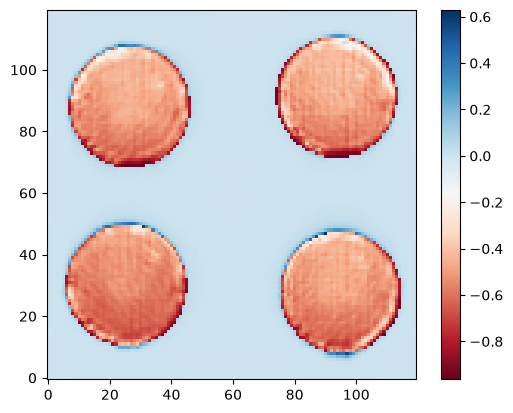

In [ ]:
# im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260802_233704.fits')
im = fits.getdata('/raid1/mmenessini/calibration/EKARUS/data/IntMat_20260815_194918.fits') #194038 #193320


imframe = im[:,399].reshape([240,240])
imframe = np.std(im,axis=1).reshape([240,240])

ref_centers = get_frame_pupil_centers(imframe)
savg_center = np.mean(ref_centers,axis=0)

hsize = 120
frimg = shift_image(imframe, shift=120-savg_center[1], axis=0)
frimg = shift_image(frimg, shift=120-savg_center[0], axis=1)
frimg = frimg[60:180,60:180]


plt.figure()
plt.imshow(frimg/np.max(frimg)-pyr_mask,origin='lower',cmap='RdBu')
plt.colorbar()

Text(0.5, 1.0, 'Difference')

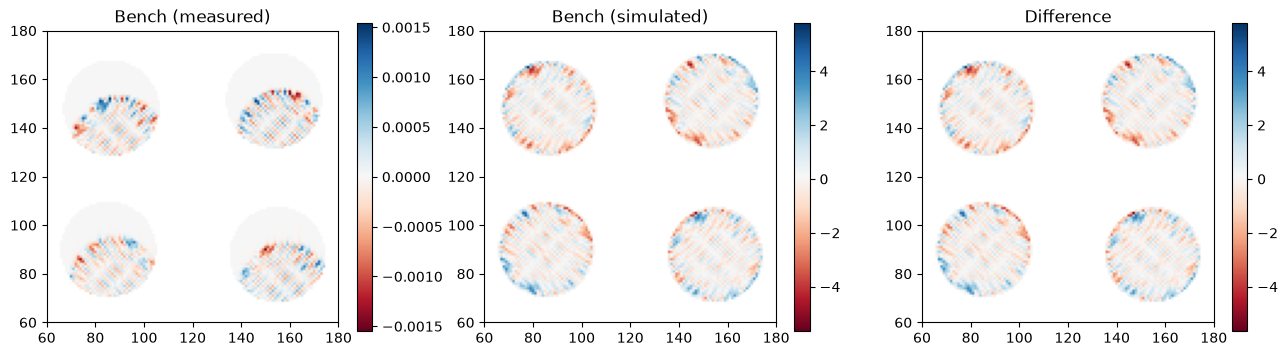

In [8]:
rMod = 5
benchim = fits.getdata(f'/raid1/mmenessini/calibration/EKARUS/im/pyr{rMod:1.1f}_onbench_measIF_dm468_im.fits')
pup_hdu = fits.open('/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')
pup_ids_bench = pup_hdu[1].data

sky_pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onsky.fits')
pyr_mask = get_pupil_mask(npix=240,filepath='/raid1/mmenessini/calibration/EKARUS/pupils/pyr_pupdata_onbench.fits')

jdx = 399
npix = 240
fimg_bench = np.zeros([npix,npix])
for i in range(400):
    rtot = 0
    for k in range(4):
        valid_ids = pup_ids_bench[:,k] != -1
        len_ids = np.sum(valid_ids)
        np.put(fimg_bench, pup_ids_bench[valid_ids,k], benchim[rtot:rtot+len_ids,i])
        rtot += len_ids
    bench2d = fimg_bench.reshape([npix,npix])
    if i == jdx:
        f2d_bench = bench2d/np.std(bench2d[pyr_mask])

f2d_meas = im[:,jdx].reshape([240,240])

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.imshow(np.ma.masked_array(f2d_meas,mask=1-pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Bench (measured)')
plt.xlim([60,180])
plt.ylim([60,180])
plt.subplot(1,3,2)
plt.imshow(np.ma.masked_array(f2d_bench,mask=1-pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Bench (simulated)')
plt.xlim([60,180])
plt.ylim([60,180])
plt.subplot(1,3,3)
plt.imshow(np.ma.masked_array(f2d_bench-f2d_meas,mask=1-pyr_mask),origin='lower',cmap='RdBu')
plt.colorbar()
plt.xlim([60,180])
plt.ylim([60,180])
plt.title('Difference')